In [1]:
## conda activate gpy_torch_env
import os
os.environ["KMP_DUPLICATE_LIB_OK"]="TRUE"

import tqdm
import torch 
from torch.autograd.functional import jacobian
from torch.distributions.multivariate_normal import MultivariateNormal
import gpytorch
import pyro
from pyro.infer import MCMC, NUTS
import pyro.distributions as dist
from scipy.linalg import eigh
import numpy as np 
import matplotlib.pyplot as plt
from scipy.integrate import odeint, solve_ivp
from scipy.stats import norm, multivariate_normal, invgamma, uniform
from scipy import interpolate
import pickle



c:\Users\mjcol\miniconda3\envs\uq_disc\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from pathlib import Path


def load_metric_file(filename):
    """
    Each pickle file contains:
        1. results dictionary
        2. summary dictionary
    """
    with open(filename, "rb") as f:
        results = pickle.load(f)
    return results

def as_2d_array(x):
    """
    Convert arrays to shape:
        n_replicates x n_parameters
    """
    arr = np.asarray(x)

    if arr.ndim == 1:
        arr = arr[:, None]

    return arr

def compare_koh_mop_boxplots(
    results,
    system_name,
    metric_label,
    koh_key,
    mop_key,
    param_names,
    save_dir="koh_vs_mop_boxplots"
):
    """
    Create one figure comparing KOH and MOP for a single metric
    within a single loaded file.
    """
    if koh_key not in results or mop_key not in results:
        print(f"Skipping {system_name} - {metric_label}: missing {koh_key} or {mop_key}")
        return

    koh_values = as_2d_array(results[koh_key]).T
    mop_values = as_2d_array(results[mop_key]).T

    print(np.shape(koh_values))

    if koh_values.shape[1] != mop_values.shape[1]:
        print(
            f"Skipping {system_name} - {metric_label}: "
            f"KOH has {koh_values.shape[1]} parameters, "
            f"MOP has {mop_values.shape[1]} parameters"
        )
        return

    n_params = 1#koh_values.shape[1]
    print(n_params)

    save_dir = Path(save_dir)
    save_dir.mkdir(exist_ok=True)

    data = []
    positions = []
    labels = []

    for param_idx in range(n_params):
        base_position = param_idx * 3

        data.append(koh_values[:, param_idx])
        positions.append(base_position)

        data.append(mop_values[:, param_idx])
        positions.append(base_position + 1)

        labels.append(f"{param_names[param_idx]}")

    plt.figure(figsize=(max(8, 1.8 * n_params), 5))
    print(np.shape(data))
    box = plt.boxplot(
        data,
        positions=positions,
        widths=0.7,
        patch_artist=True,
        showmeans=False,
        showfliers=False    
        )

    for i, patch in enumerate(box["boxes"]):
        if i % 2 == 0:
            patch.set_alpha(0.4)
            patch.set_label("KOH" if i == 0 else "")
        else:
            patch.set_alpha(0.9)
            patch.set_label("MOP" if i == 1 else "")

    xtick_positions = [param_idx * 3 + 0.5 for param_idx in range(n_params)]

    plt.xticks(
        xtick_positions,
        labels,
        rotation=45,
        ha="right"
    )

    plt.title(f"{system_name}: KOH vs MOP {metric_label}")
    plt.xlabel("Parameter")
    plt.axhline(y=0,color='black',linestyle='--')
    plt.ylabel(metric_label)

    handles = [
        box["boxes"][0],
        box["boxes"][1],
    ]
    plt.legend(handles, ["KOH", "MOP"])

    plt.tight_layout()

    output_file = save_dir / f"{system_name}_{metric_label}_KOH_vs_MOP_boxplot.png"
    # plt.savefig(output_file, dpi=300, bbox_inches="tight")
    plt.show()

def plot_all_koh_mop_metric_comparisons(metric_files, metrics_to_compare):
    """
    For each loaded file, create separate figures for:
        bias
        RMSE
        coverage
    """
    for system_name, filename in metric_files.items():
        results = load_metric_file(filename)


        param_labels = parameter_names[system_name]    
        for metric_label, (koh_key, mop_key) in metrics_to_compare.items():
            compare_koh_mop_boxplots(
                results=results,
                system_name=system_name,
                metric_label=metric_label,
                koh_key=koh_key,
                mop_key=mop_key,
                param_names=param_labels
            )


In [3]:
with open("FourSpring_prediction_metrics_Final.pkl", "rb") as f:
    results = pickle.load(f)


data = []
positions = []
labels = []
for metric_name, stats in results.items():
    print(f"\n{metric_name}")
    print(f"Mean:{torch.mean(stats)}")
    print(f"Median:{torch.median(stats)}")
    # print(f"Variance:{torch.var(stats)} \n")





IND_RMSE_storage
Mean:0.30253657698631287
Median:0.2650739848613739

IND_bias_storage
Mean:-0.0060264975763857365
Median:-0.00261495029553771

IND_cover_storage
Mean:0.9714500308036804
Median:1.0

IND_interval_storage
Mean:1.774842381477356
Median:1.6814420223236084

MOP_RMSE_storage
Mean:0.2984617352485657
Median:0.2641386091709137

MOP_bias_storage
Mean:-0.005992061458528042
Median:-0.0032462114468216896

MOP_cover_storage
Mean:0.967987596988678
Median:1.0

MOP_interval_storage
Mean:1.676411747932434
Median:1.568910837173462


In [10]:
with open("TwoSpring_prediction_metrics_Final.pkl", "rb") as f:
    results = pickle.load(f)


data = []
positions = []
labels = []
for metric_name, stats in results.items():
    print(f"\n{metric_name}")
    print(f"Mean:{torch.mean(stats)}")
    print(f"Median:{torch.median(stats)}")
    # print(f"Variance:{torch.var(stats)} \n")





IND_RMSE_storage
Mean:0.3133206069469452
Median:0.2656378149986267

IND_bias_storage
Mean:-0.017378967255353928
Median:-0.009963705204427242

IND_cover_storage
Mean:0.9894999861717224
Median:1.0

IND_interval_storage
Mean:2.093507766723633
Median:1.928010106086731

MOP_RMSE_storage
Mean:0.30833765864372253
Median:0.27148619294166565

MOP_bias_storage
Mean:-0.0176909938454628
Median:-0.010242667980492115

MOP_cover_storage
Mean:0.9788249731063843
Median:1.0

MOP_interval_storage
Mean:1.8588708639144897
Median:1.636474847793579


In [5]:
with open("SIRV_IRV_prediction_metrics_Final.pkl", "rb") as f:
    results = pickle.load(f)


data = []
positions = []
labels = []
for metric_name, stats in results.items():
    print(f"\n{metric_name}")
    print(f"Mean:{torch.mean(stats)}")
    print(f"Median:{torch.median(stats)}")
    # print(f"Variance:{torch.var(stats)} \n")





IND_RMSE_storage
Mean:0.01941525563597679
Median:0.01580977253615856

IND_bias_storage
Mean:-0.000436036178143695
Median:-3.5873352317139506e-05

IND_cover_storage
Mean:0.9887999892234802
Median:1.0

IND_interval_storage
Mean:0.16573186218738556
Median:0.1396980583667755

MOP_RMSE_storage
Mean:0.01871783658862114
Median:0.015205759555101395

MOP_bias_storage
Mean:-0.0004978527431376278
Median:0.00017931655747815967

MOP_cover_storage
Mean:0.9547333717346191
Median:1.0

MOP_interval_storage
Mean:0.10823657363653183
Median:0.09087146073579788


In [7]:
with open("SIRV_IV_prediction_metrics_Final.pkl", "rb") as f:
    results = pickle.load(f)


data = []
positions = []
labels = []
for metric_name, stats in results.items():
    print(f"\n{metric_name}")
    print(f"Mean:{torch.mean(stats)}")
    print(f"Median:{torch.median(stats)}")
    # print(f"Variance:{torch.var(stats)} \n")





IND_RMSE_storage
Mean:0.017314206808805466
Median:0.01399973500519991

IND_bias_storage
Mean:-0.0015390886692330241
Median:-0.0009112512925639749

IND_cover_storage
Mean:1.0
Median:1.0

IND_interval_storage
Mean:0.25331005454063416
Median:0.22777482867240906

MOP_RMSE_storage
Mean:0.015894543379545212
Median:0.012639552354812622

MOP_bias_storage
Mean:-0.0013677687384188175
Median:-0.0006997428135946393

MOP_cover_storage
Mean:1.0
Median:1.0

MOP_interval_storage
Mean:0.18849943578243256
Median:0.16538608074188232


In [9]:
with open("Fitz_preditction_metrics_Final.pkl", "rb") as f:
    results = pickle.load(f)


data = []
positions = []
labels = []
for metric_name, stats in results.items():
    print(f"\n{metric_name}")
    print(f"Mean:{torch.mean(stats)}")
    print(f"Median:{torch.median(stats)}")
    # print(f"Variance:{torch.var(stats)} \n")





IND_RMSE_storage
Mean:0.2952306568622589
Median:0.2303619533777237

IND_bias_storage
Mean:0.0055512720718979836
Median:-0.003423041198402643

IND_cover_storage
Mean:0.9999499320983887
Median:1.0

IND_interval_storage
Mean:3.224066972732544
Median:2.740468978881836

MOP_RMSE_storage
Mean:0.2886795401573181
Median:0.2239416241645813

MOP_bias_storage
Mean:0.00516154570505023
Median:-0.0004377874720375985

MOP_cover_storage
Mean:1.0
Median:1.0

MOP_interval_storage
Mean:2.6822898387908936
Median:2.260932445526123


(100, 4)
4


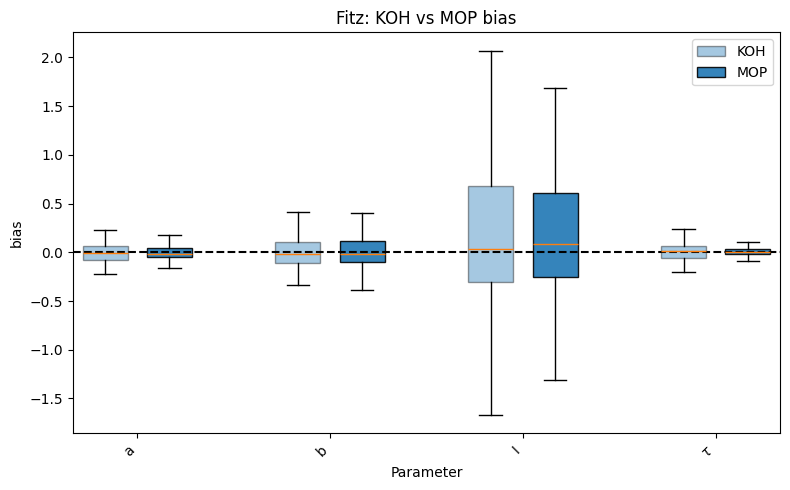

(100, 4)
4


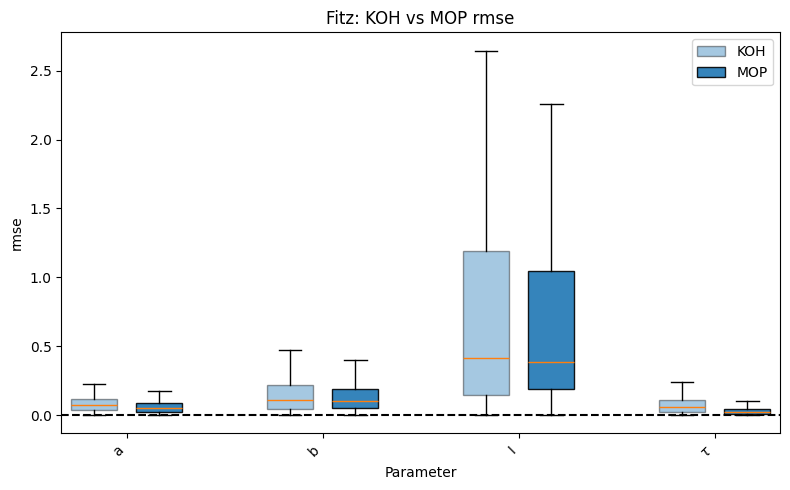

(100, 4)
4


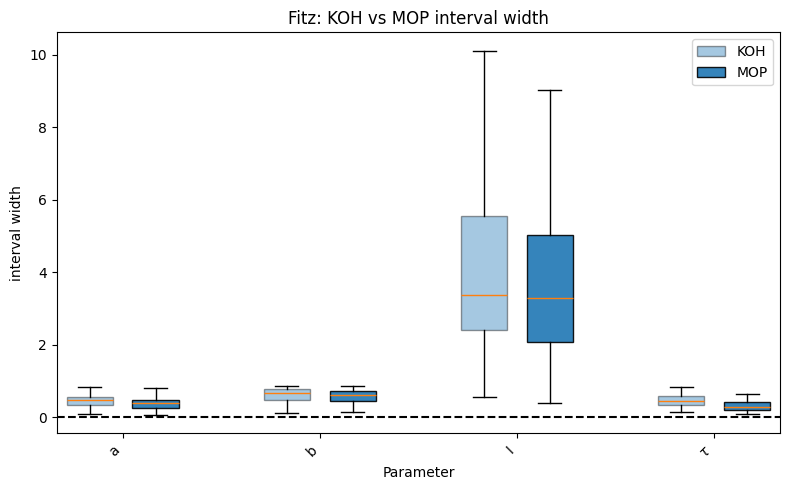

In [15]:
from pathlib import Path
metric_files = {
    # "FourSprings": "FourSprings_posterior_metrics.pkl",
    # "TwoSprings": "TwoSprings_posterior_metrics.pkl",
    # "SIRV_IRV": "SIRV_IRV_posterior_metrics_V2.pkl",
    # "SIRV_IV": "SIRV_IV_posterior_metrics_V2.pkl",
    "Fitz": "Fitz_posterior_metrics_Final.pkl",
}

metrics_to_compare = {
    "bias": ("bias_KOH", "bias_MOP"),
    "rmse": ("RMSE_KOH", "RMSE_MOP"),
    "interval width": ("int_wid_KOH", "int_wid_MOP"),
}

parameter_names = {
    "FourSprings": ('k1','c1','k2','c2','k3','c3','k4','c4'),
    "TwoSprings": ('k1','c1','k2','c2'),
    "SIRV_IRV": ('a','v',r'$mu$','wr','wv'),
    "SIRV_IV": ('a','v',r'$mu$','wr','wv'),
    "Fitz": ('a','b','I',r'$\tau$'),
    
    
}

def load_metric_file(filename):
    """
    Each pickle file contains:
        1. results dictionary
        2. summary dictionary
    """
    with open(filename, "rb") as f:
        results = pickle.load(f)
        summary = pickle.load(f)
    return results, summary

def as_2d_array(x):
    """
    Convert arrays to shape:
        n_replicates x n_parameters
    """
    arr = np.asarray(x)

    if arr.ndim == 1:
        arr = arr[:, None]

    return arr

def compare_koh_mop_boxplots(
    results,
    system_name,
    metric_label,
    koh_key,
    mop_key,
    param_names,
    save_dir="koh_vs_mop_boxplots"
):
    """
    Create one figure comparing KOH and MOP for a single metric
    within a single loaded file.
    """
    if koh_key not in results or mop_key not in results:
        print(f"Skipping {system_name} - {metric_label}: missing {koh_key} or {mop_key}")
        return

    koh_values = as_2d_array(results[koh_key]).T
    mop_values = as_2d_array(results[mop_key]).T

    print(np.shape(koh_values))

    if koh_values.shape[1] != mop_values.shape[1]:
        print(
            f"Skipping {system_name} - {metric_label}: "
            f"KOH has {koh_values.shape[1]} parameters, "
            f"MOP has {mop_values.shape[1]} parameters"
        )
        return

    n_params = koh_values.shape[1]
    print(n_params)

    save_dir = Path(save_dir)
    save_dir.mkdir(exist_ok=True)

    data = []
    positions = []
    labels = []

    for param_idx in range(n_params):
        base_position = param_idx * 3

        data.append(koh_values[:, param_idx])
        positions.append(base_position)

        data.append(mop_values[:, param_idx])
        positions.append(base_position + 1)

        labels.append(f"{param_names[param_idx]}")

    plt.figure(figsize=(max(8, 1.8 * n_params), 5))

    box = plt.boxplot(
        data,
        positions=positions,
        widths=0.7,
        patch_artist=True,
        showmeans=False,
        showfliers=False    
        )

    for i, patch in enumerate(box["boxes"]):
        if i % 2 == 0:
            patch.set_alpha(0.4)
            patch.set_label("KOH" if i == 0 else "")
        else:
            patch.set_alpha(0.9)
            patch.set_label("MOP" if i == 1 else "")

    xtick_positions = [param_idx * 3 + 0.5 for param_idx in range(n_params)]

    plt.xticks(
        xtick_positions,
        labels,
        rotation=45,
        ha="right"
    )

    plt.title(f"{system_name}: KOH vs MOP {metric_label}")
    plt.xlabel("Parameter")
    plt.axhline(y=0,color='black',linestyle='--')
    plt.ylabel(metric_label)

    handles = [
        box["boxes"][0],
        box["boxes"][1],
    ]
    plt.legend(handles, ["KOH", "MOP"])

    plt.tight_layout()

    output_file = save_dir / f"{system_name}_{metric_label}_KOH_vs_MOP_boxplot.png"
    # plt.savefig(output_file, dpi=300, bbox_inches="tight")
    plt.show()

def plot_all_koh_mop_metric_comparisons(metric_files, metrics_to_compare):
    """
    For each loaded file, create separate figures for:
        bias
        RMSE
        coverage
    """
    for system_name, filename in metric_files.items():
        results, summary = load_metric_file(filename)


        param_labels = parameter_names[system_name]    
        for metric_label, (koh_key, mop_key) in metrics_to_compare.items():
            compare_koh_mop_boxplots(
                results=results,
                system_name=system_name,
                metric_label=metric_label,
                koh_key=koh_key,
                mop_key=mop_key,
                param_names=param_labels
            )

plot_all_koh_mop_metric_comparisons(metric_files, metrics_to_compare)